In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection

In [ ]:
inspection.inspect_model('resnet101')

In [2]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='38', run_id='010212ceb9334af3b57453273e173d2a')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1586.)
  tensor = torch.frombuffer(


Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:38//data/model.pt2


In [4]:
model.predict(torch.randn(1,3,2048,2048))

(51655.0,
 tensor([[[0.0049, 0.0060, 0.0074,  ..., 0.0056, 0.0042, 0.0019],
          [0.0057, 0.0078, 0.0095,  ..., 0.0072, 0.0055, 0.0028],
          [0.0059, 0.0094, 0.0107,  ..., 0.0086, 0.0068, 0.0034],
          ...,
          [0.0010, 0.0005, 0.0007,  ..., 0.0030, 0.0026, 0.0018],
          [0.0009, 0.0005, 0.0008,  ..., 0.0021, 0.0019, 0.0015],
          [0.0005, 0.0007, 0.0005,  ..., 0.0010, 0.0009, 0.0010]]],
        device='cuda:0'))

In [8]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

182 images found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/images
182 h5 files found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/ground-truth-h5


In [9]:
model.evaluate(datamodule)

tensor([604.0668], device='cuda:0') tensor([171.8294], device='cuda:0')
tensor([506.9254], device='cuda:0') tensor([497.0637], device='cuda:0')
tensor([432.9359], device='cuda:0') tensor([381.9256], device='cuda:0')
tensor([656.7045], device='cuda:0') tensor([210.3973], device='cuda:0')
tensor([260.8564], device='cuda:0') tensor([217.3769], device='cuda:0')
tensor([552.6545], device='cuda:0') tensor([427.6055], device='cuda:0')
tensor([1512.9216], device='cuda:0') tensor([1163.2383], device='cuda:0')
tensor([236.9610], device='cuda:0') tensor([257.0872], device='cuda:0')
tensor([1059.9448], device='cuda:0') tensor([1225.8103], device='cuda:0')
tensor([204.0250], device='cuda:0') tensor([288.4334], device='cuda:0')
tensor([240.1390], device='cuda:0') tensor([175.6181], device='cuda:0')
tensor([402.5147], device='cuda:0') tensor([373.5144], device='cuda:0')
tensor([1076.3163], device='cuda:0') tensor([1063.9664], device='cuda:0')
tensor([811.7331], device='cuda:0') tensor([1016.6429], de

{'MAE': 83.80721282958984, 'MSE': 17627.40234375, 'NAE': 0.26362845301628113}

In [29]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [15]:
from torchvision.transforms import v2
from PIL import Image
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/hama_2025_2.jpg').convert('RGB')
image = helpers.transform_sample(original_image, params)

In [16]:
result  = model.predict(image)
result

(3272.9951171875,
 tensor([[[0.0009, 0.0006, 0.0006,  ..., 0.0005, 0.0006, 0.0005],
          [0.0004, 0.0004, 0.0004,  ..., 0.0002, 0.0004, 0.0004],
          [0.0003, 0.0003, 0.0003,  ..., 0.0002, 0.0003, 0.0003],
          ...,
          [0.0003, 0.0002, 0.0001,  ..., 0.0002, 0.0002, 0.0003],
          [0.0004, 0.0002, 0.0002,  ..., 0.0002, 0.0003, 0.0005],
          [0.0004, 0.0004, 0.0004,  ..., 0.0003, 0.0003, 0.0005]]]))

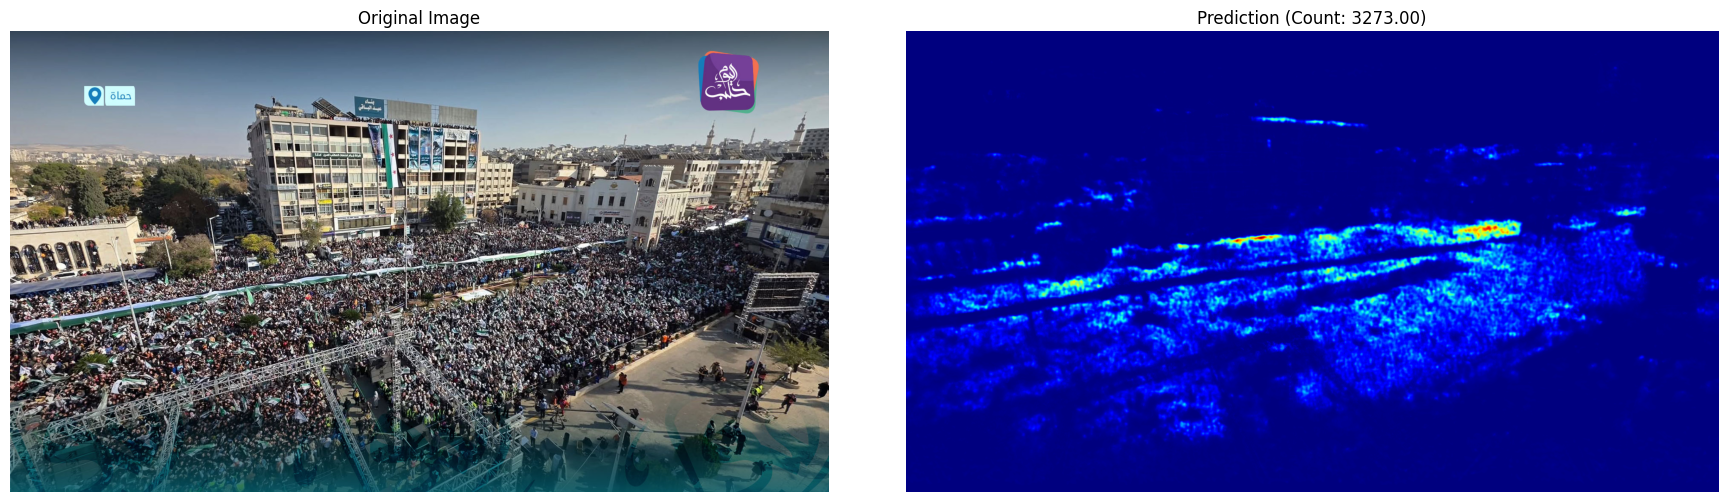

In [17]:
vis.visualize_sample(original_image, pred=result)

In [18]:
from src.models.model import CrowdCounter


crowd_model = CrowdCounter(params=params)
crowd_model.eval()
crowd_model.load_state_dict(model.model.state_dict())

RuntimeError: Error(s) in loading state_dict for CrowdCounter:
	Missing key(s) in state_dict: "net.net.encoder._conv_stem.weight", "net.net.encoder._bn0.weight", "net.net.encoder._bn0.bias", "net.net.encoder._bn0.running_mean", "net.net.encoder._bn0.running_var", "net.net.encoder._blocks.0._depthwise_conv.weight", "net.net.encoder._blocks.0._bn1.weight", "net.net.encoder._blocks.0._bn1.bias", "net.net.encoder._blocks.0._bn1.running_mean", "net.net.encoder._blocks.0._bn1.running_var", "net.net.encoder._blocks.0._se_reduce.weight", "net.net.encoder._blocks.0._se_reduce.bias", "net.net.encoder._blocks.0._se_expand.weight", "net.net.encoder._blocks.0._se_expand.bias", "net.net.encoder._blocks.0._project_conv.weight", "net.net.encoder._blocks.0._bn2.weight", "net.net.encoder._blocks.0._bn2.bias", "net.net.encoder._blocks.0._bn2.running_mean", "net.net.encoder._blocks.0._bn2.running_var", "net.net.encoder._blocks.1._depthwise_conv.weight", "net.net.encoder._blocks.1._bn1.weight", "net.net.en

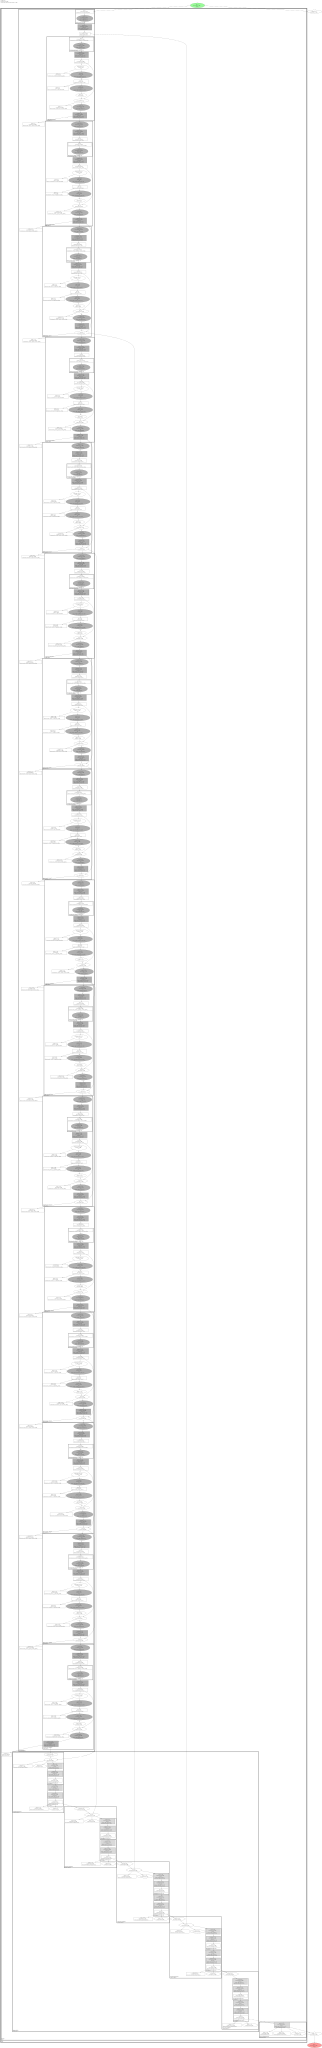

[Errno 2] No such file or directory: 'xdg-open'


In [11]:
vis.visualize_model_graph(crowd_model, sample=sample)